In [2]:
# Dataset Description
# Source: U.S. Chronic Disease Indicators (data.gov)
# Goal: Predict high-risk disease cases
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Load Data
from google.colab import drive
drive.mount('/content/drive/')

# Read the dataset
df = pd.read_csv("/content/drive/MyDrive/U.S._Chronic_Disease_Indicators.csv")

# Display first 5 rows
df.head()

Mounted at /content/drive/


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [ ]:
#Data understanding
print(df.shape)
print(df.info())
print(df.describe())

(309215, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnot

In [3]:
#Missing Values
print(df.isnull().sum())

YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
DataSource                        0
Topic                             0
Question                          0
Response                     309215
DataValueUnit                     0
DataValueType                     0
DataValue                    100019
DataValueAlt                 100019
DataValueFootnoteSymbol      207499
DataValueFootnote            207499
LowConfidenceLimit           120330
HighConfidenceLimit          120325
StratificationCategory1           0
Stratification1                   0
StratificationCategory2      309215
Stratification2              309215
StratificationCategory3      309215
Stratification3              309215
Geolocation                    5763
LocationID                        0
TopicID                           0
QuestionID                        0
ResponseID                   309215
DataValueTypeID             

In [4]:
#Data cleaning
# Drop rows with missing target values
df = df.dropna(subset=['DataValue'])

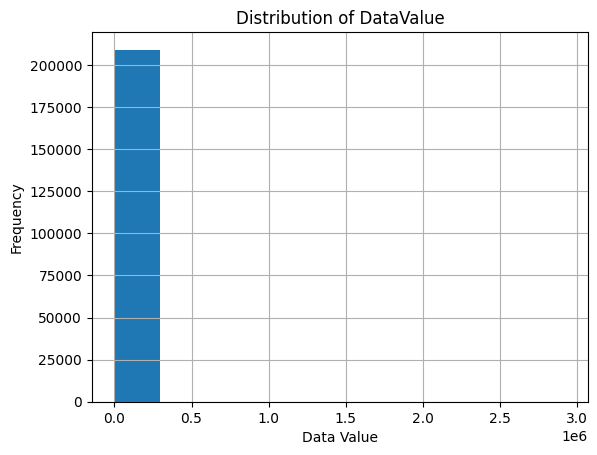

In [5]:
# 5. EXPLORATORY DATA ANALYSIS
#Univariate Visualization
plt.figure()
df['DataValue'].hist()
plt.title('Distribution of DataValue')
plt.xlabel('Data Value')
plt.ylabel('Frequency')
plt.show()

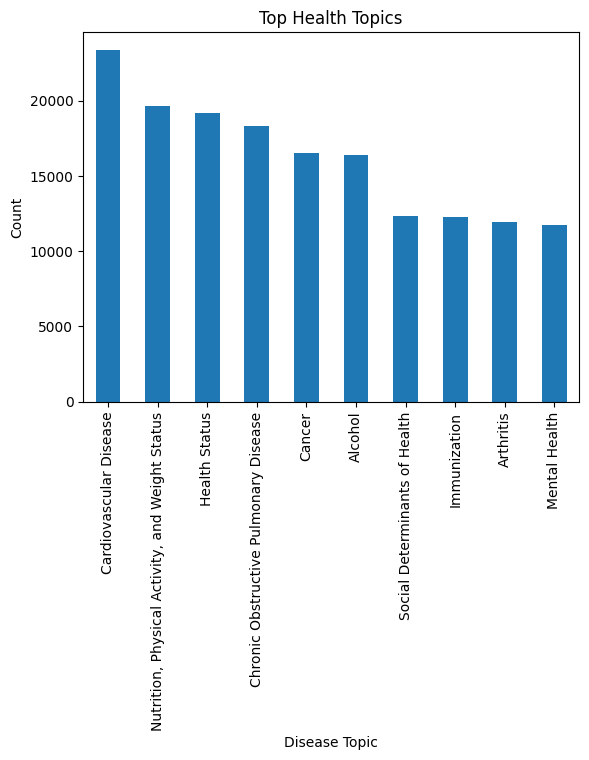

In [6]:
#Univariate Visualization
# Top topics
plt.figure()
df['Topic'].value_counts().head(10).plot(kind='bar')
plt.title('Top Health Topics')
plt.xlabel('Disease Topic')
plt.ylabel('Count')
plt.show()

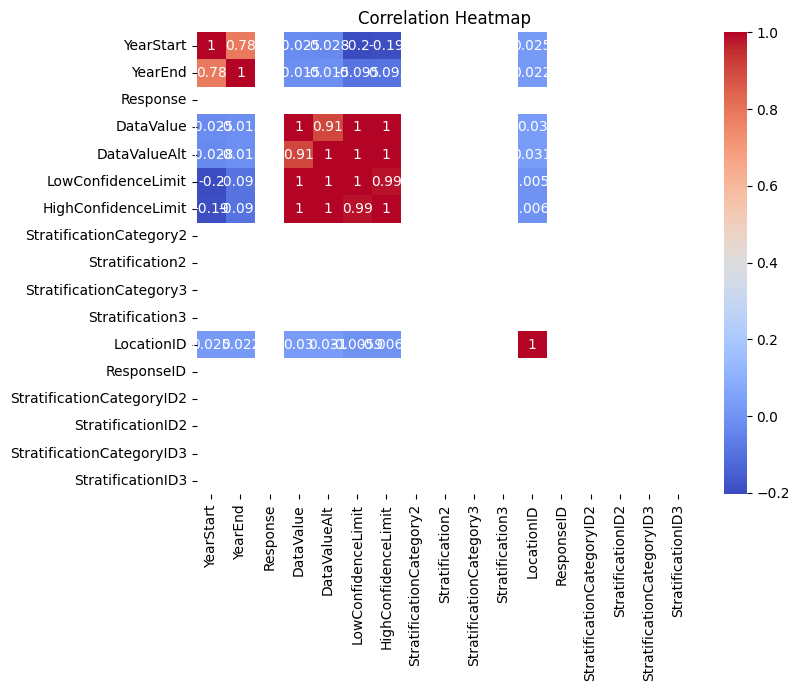

In [7]:
#Multivariant Visualization
#Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

df_ml = df[['LocationDesc', 'Topic', 'StratificationCategory1']].copy()

le_location = LabelEncoder()
le_topic = LabelEncoder()
le_strat = LabelEncoder()

df_ml['LocationDesc'] = le_location.fit_transform(df_ml['LocationDesc'].astype(str))
df_ml['Topic'] = le_topic.fit_transform(df_ml['Topic'].astype(str))
df_ml['StratificationCategory1'] = le_strat.fit_transform(df_ml['StratificationCategory1'].astype(str))

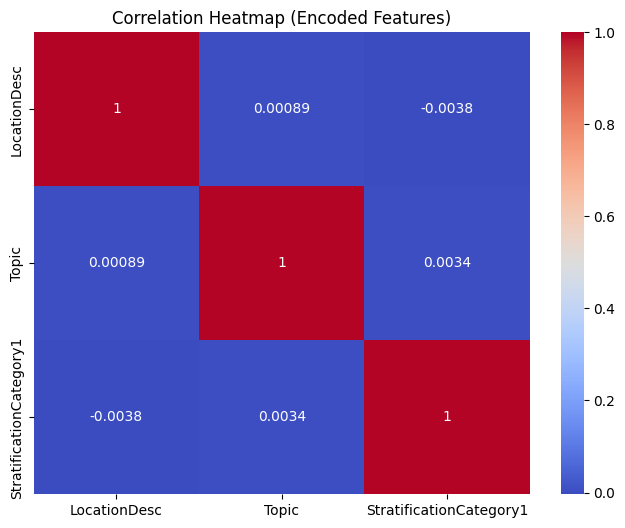

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(df_ml.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap (Encoded Features)')
plt.show()

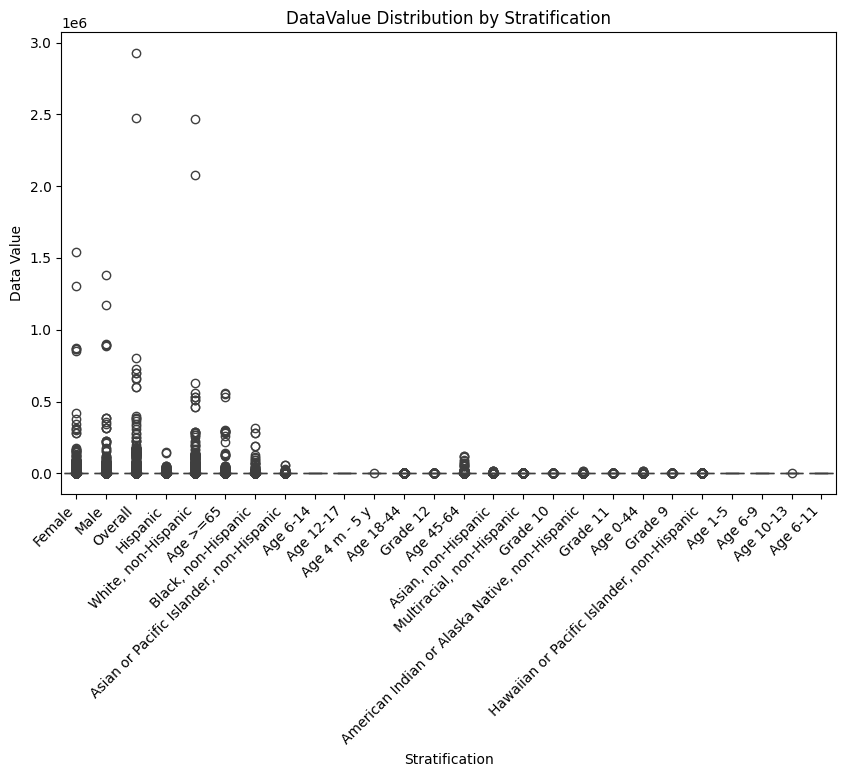

In [10]:
#Multivariant Visualization
#Box plot
plt.figure(figsize=(10,6))

sns.boxplot(x='Stratification1', y='DataValue', data=df)

plt.title('DataValue Distribution by Stratification')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Stratification')
plt.ylabel('Data Value')
plt.show()

In [11]:
# 6. FEATURE SELECTION
df_ml = df[['LocationDesc', 'Topic', 'Stratification1', 'DataValue']].copy()

In [12]:
# Create target variable
threshold = df_ml['DataValue'].mean()
df_ml['HighRisk'] = (df_ml['DataValue'] > threshold).astype(int)

In [13]:
# Drop original target column
df_ml = df_ml.drop('DataValue', axis=1)

In [14]:
#Encoding
le_location = LabelEncoder()
le_topic = LabelEncoder()
le_strat = LabelEncoder()

df_ml['LocationDesc'] = le_location.fit_transform(df_ml['LocationDesc'].astype(str))
df_ml['Topic'] = le_topic.fit_transform(df_ml['Topic'].astype(str))
df_ml['Stratification1'] = le_strat.fit_transform(df_ml['Stratification1'].astype(str))

In [15]:
#Split data
X = df_ml.drop('HighRisk', axis=1)
y = df_ml['HighRisk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
lr = LogisticRegression(class_weight='balanced', solver='liblinear') # Added class_weight='balanced' and a stable solver
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results (with class weights)")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results (with class weights)
Accuracy: 0.6198135755258126
[[24454 15526]
 [  381  1479]]
              precision    recall  f1-score   support

           0       0.98      0.61      0.75     39980
           1       0.09      0.80      0.16      1860

    accuracy                           0.62     41840
   macro avg       0.54      0.70      0.46     41840
weighted avg       0.94      0.62      0.73     41840



In [19]:
print("Distribution of 'HighRisk' in the target variable:")
print(y.value_counts())

Distribution of 'HighRisk' in the target variable:
HighRisk
0    199898
1      9298
Name: count, dtype: int64


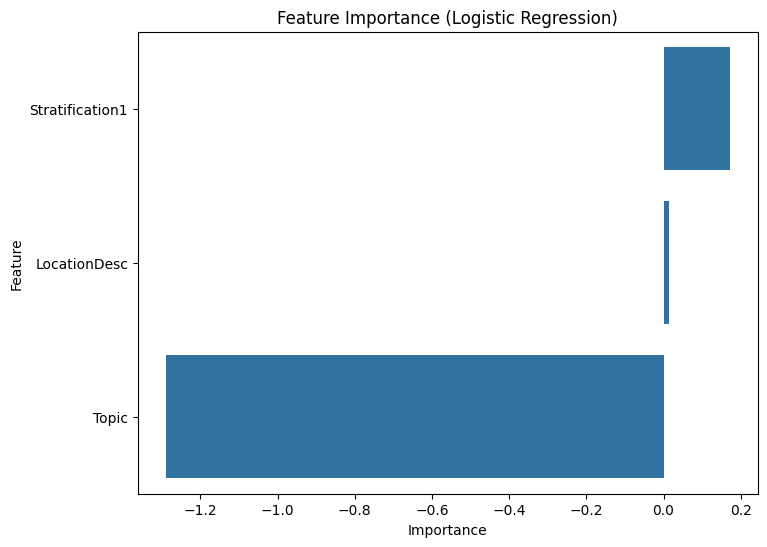

In [20]:
#Logistic Regression
# Get feature importance (coefficients)
feature_names = X.columns
coefficients = lr.coef_[0]

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Sort values
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)

plt.title('Feature Importance (Logistic Regression)')
plt.show()

In [21]:
#NEURAL NETWORK MODEL
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Evaluate NN
loss, accuracy = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9532 - loss: 0.1567
Epoch 2/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9556 - loss: 0.1407
Epoch 3/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1397
Epoch 4/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9556 - loss: 0.1389
Epoch 5/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1382
Epoch 6/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1376
Epoch 7/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1374
Epoch 8/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9556 - loss: 0.1371
Epoch 9/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1368
Epoch 10/10
5230/5230 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9556 - loss: 0.1366
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9555 - loss: 0.1378
Neural Network Accuracy: 0.95554

In [22]:
#SIMPLE PREDICTION FUNCTION
def predict_risk(location, topic, stratification):
    loc = le_location.transform([location])[0]
    top = le_topic.transform([topic])[0]
    strat = le_strat.transform([stratification])[0]

    data = np.array([[loc, top, strat]])
    data = scaler.transform(data)

    prediction = lr.predict(data)
    return "High Risk" if prediction[0] == 1 else "Low Risk"

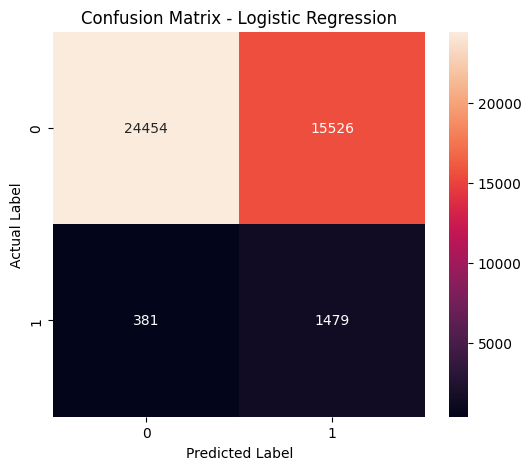

In [23]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

<Axes: >

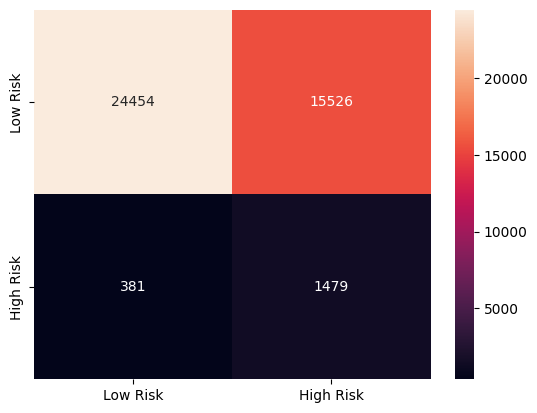

In [24]:
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])

In [25]:
import gradio as gr

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Re-load df to ensure it's defined
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/U.S._Chronic_Disease_Indicators.csv")

# Drop rows with missing target values, as done in cell GN_F_UY4G-sm
df = df.dropna(subset=['DataValue'])

# Re-create df_ml and all dependencies for Gradio interface to ensure they are defined
# Create df_ml as done in cell 2EswjvMVP-9G
df_ml_gradio = df[['LocationDesc', 'Topic', 'Stratification1', 'DataValue']].copy()

# Create target variable as done in cell N_wIoEJ6n5nm
threshold_gradio = df_ml_gradio['DataValue'].mean()
df_ml_gradio['HighRisk'] = (df_ml_gradio['DataValue'] > threshold_gradio).astype(int)

# Drop original target column as done in cell D0LZE6WyoBG-
df_ml_gradio = df_ml_gradio.drop('DataValue', axis=1)

# Initialize and fit LabelEncoders as done in cell r1odvMLVoEbO
le_location = LabelEncoder()
le_topic = LabelEncoder()
le_strat = LabelEncoder()

df_ml_gradio['LocationDesc'] = le_location.fit_transform(df_ml_gradio['LocationDesc'].astype(str))
df_ml_gradio['Topic'] = le_topic.fit_transform(df_ml_gradio['Topic'].astype(str))
df_ml_gradio['Stratification1'] = le_strat.fit_transform(df_ml_gradio['Stratification1'].astype(str))

# Split data as done in cell S6AEwF2LoTiP
X = df_ml_gradio.drop('HighRisk', axis=1)
y = df_ml_gradio['HighRisk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data as done in cell eo8tBJyzofpL
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model as done in cell VAKT2a_XonvO
lr = LogisticRegression(class_weight='balanced', solver='liblinear') # Added class_weight='balanced' and a stable solver
lr.fit(X_train, y_train)

# Define predict_risk function as done in cell 5vlDYKWqpBuJ
def predict_risk(location, topic, stratification):
    loc = le_location.transform([location])[0]
    top = le_topic.transform([topic])[0]
    strat = le_strat.transform([stratification])[0]

    data = np.array([[loc, top, strat]])
    data = scaler.transform(data)

    prediction = lr.predict(data)
    return "High Risk" if prediction[0] == 1 else "Low Risk"


# Get unique values for dropdowns (using df_ml_gradio *before* encoding for display)
# We will extract options from the original df_ml at the stage before encoding, for human readability.
original_df_ml_for_options = df[['LocationDesc', 'Topic', 'Stratification1']].copy()
location_options = original_df_ml_for_options['LocationDesc'].unique().tolist()
topic_options = original_df_ml_for_options['Topic'].unique().tolist()
stratification_options = original_df_ml_for_options['Stratification1'].unique().tolist()

Mounted at /content/drive/


In [ ]:
# Create Gradio Interface
iface = gr.Interface(
    fn=predict_risk,
    inputs=[
        gr.Dropdown(location_options, label="Location Description"),
        gr.Dropdown(topic_options, label="Topic"),
        gr.Dropdown(stratification_options, label="Stratification")
    ],
    outputs="text",
    title="High-Risk Disease Prediction",
    description="Predict if a case is high-risk based on location, topic, and stratification."
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a969ed1ef5b4e2d483.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut